# HyperElasticity JAX API Demo

The pure-JAX hyperelasticity path is serial and load-step based. This demo runs a lightweight `level 1` / `4 of 24` trajectory through the canonical API.

Relevant docs:
- [docs/problems/HyperElasticity.md](../../docs/problems/HyperElasticity.md)
- [docs/results/HyperElasticity.md](../../docs/results/HyperElasticity.md)


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

REPO_ROOT = Path.cwd()
ARTIFACT_ROOT = Path("artifacts/raw_results/notebook_runs")
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
PYTHON = REPO_ROOT / ".venv" / "bin" / "python"

def dump_json(path):
    with open(path, encoding="utf-8") as handle:
        return json.load(handle)


In [2]:
import matplotlib.pyplot as plt
from src.problems.hyperelasticity.jax.solve_HE_jax_newton import run_level

result = run_level(level=1, steps=4, total_steps=24, verbose=False)
summary = {
    "level": result["level"],
    "completed_steps": len(result["steps"]),
    "result": result["result"],
    "total_newton_iters": result["total_newton_iters"],
    "final_energy": float(result["steps"][-1]["energy"]),
}
summary


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


{'level': 1,
 'completed_steps': 4,
 'result': 'completed',
 'total_newton_iters': 90,
 'final_energy': 5.540151887846902}

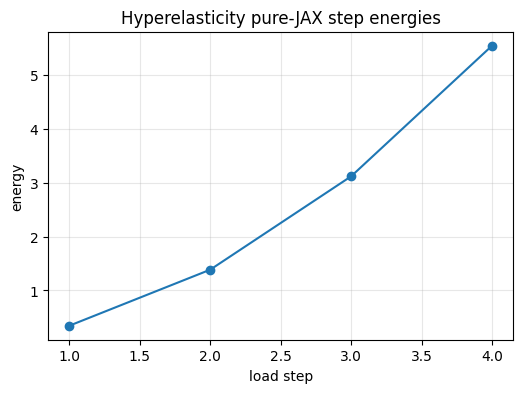

In [3]:
step_ids = [row["step"] for row in result["steps"]]
energies = [row["energy"] for row in result["steps"]]

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(step_ids, energies, marker="o")
ax.set_xlabel("load step")
ax.set_ylabel("energy")
ax.set_title("Hyperelasticity pure-JAX step energies")
ax.grid(True, alpha=0.3)
plt.show()
